In [2]:
import pandas as pd

# Load the cleaned dataset
new_df = pd.read_csv("../data/cleaned/heart_disease_cleaned.csv")

# Display the first five rows
new_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


In [3]:
# Import the remaining libraries

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Split the dataset
from sklearn.model_selection import train_test_split

# Data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Connect preprocessing and models
from sklearn.pipeline import Pipeline

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save and load the final model
import joblib

In [4]:
# Check the dataset shape

print("Dataset shape:", new_df.shape)

Dataset shape: (1024, 15)


## Define Input Features and Target

Separate the input features from the target variable.

The input features are used by the model to make predictions, while `target_binary` is the class the model will predict.

In [5]:
# Continuous numerical features
numeric_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Categorical features represented using numbers
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]


In [11]:
# Combine all input features
features = numeric_features + categorical_features



In [7]:

# X contains the input features
X = new_df[features].copy()

# y contains the target variable
y = new_df["target_binary"].copy()


In [8]:
X.shape

(1024, 13)

In [9]:
y.shape

(1024,)

## Train Machine Learning Models

Two classification models will be trained and compared:

- Logistic Regression
- Decision Tree

Both models will use the same training and testing data.

## Train-Test Split

Split the dataset into training and testing sets.

The training set is used to train the model.

The testing set is used to evaluate the model on data it has not seen during training.

In [ ]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Display the shapes of the training and testing sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (819, 13)
X_test shape: (205, 13)
y_train shape: (819,)
y_test shape: (205,)


## Data Preprocessing

Numerical features are standardized using StandardScaler.

Categorical features are converted into numerical binary columns using OneHotEncoder.

ColumnTransformer applies the correct preprocessing method to each feature type.

In [14]:
# Preprocess numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Logistic Regression Model

Train a Logistic Regression model using the preprocessed features.

Logistic Regression is used for binary classification because the target contains two classes, 0 and 1.

In [15]:
# Create the Logistic Regression pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

second model to train 

In [18]:
# Create the Decision Tree model

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

Train both models

In [19]:
# Train Logistic Regression
logistic_model.fit(X_train, y_train)

# Train Decision Tree
tree_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


In [20]:
# Make predictions

# Predict the test data
logistic_pred = logistic_model.predict(X_test)
tree_pred = tree_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


## Model Evaluation

Evaluate the performance of Logistic Regression and Decision Tree using accuracy, precision, recall, and F1-score.

In [29]:
# Evaluate Logistic Regression

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_precision = precision_score(y_test, logistic_pred)
logistic_recall = recall_score(y_test, logistic_pred)
logistic_f1 = f1_score(y_test, logistic_pred)

print("Logistic Regression")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-Score:", logistic_f1)

Logistic Regression
Accuracy: 0.8780487804878049
Precision: 0.8850574712643678
Recall: 0.8369565217391305
F1-Score: 0.8603351955307262


In [30]:
# Decision Tree evaluation
print("DECISION TREE")
print("Accuracy :", round(accuracy_score(y_test, tree_pred), 4))
print("Precision:", round(precision_score(y_test, tree_pred), 4))
print("Recall   :", round(recall_score(y_test, tree_pred), 4))
print("F1-score :", round(f1_score(y_test, tree_pred), 4))

DECISION TREE
Accuracy : 0.8
Precision: 0.7802
Recall   : 0.7717
F1-score : 0.776


Create a model-comparison table

In [31]:
# Store both models' results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, tree_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, tree_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, tree_pred)
    ],
    "F1-score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, tree_pred)
    ]
})

# Display rounded results
results.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.878,0.8851,0.8370,0.8603
1,Decision Tree,0.800,0.7802,0.7717,0.7760


Select the best model

In [32]:
# Find the model with the highest F1-score

best_model_name = results.loc[
    results["F1-score"].idxmax(),
    "Model"
]

# Select the trained pipeline
if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_predictions = logistic_pred
else:
    best_model = tree_model
    best_predictions = tree_pred

print("Best model:", best_model_name)

Best model: Logistic Regression


Create the confusion matrix

In [33]:
# Calculate the confusion matrix
cm = confusion_matrix(
    y_test,
    best_predictions
)

# Display it as a table
confusion_df = pd.DataFrame(
    cm,
    index=[
        "Actual Lower Risk",
        "Actual Higher Risk"
    ],
    columns=[
        "Predicted Lower Risk",
        "Predicted Higher Risk"
    ]
)

confusion_df

,Predicted Lower Risk,Predicted Higher Risk
Actual Lower Risk,103,10
Actual Higher Risk,15,77


Draw the confusion matrix

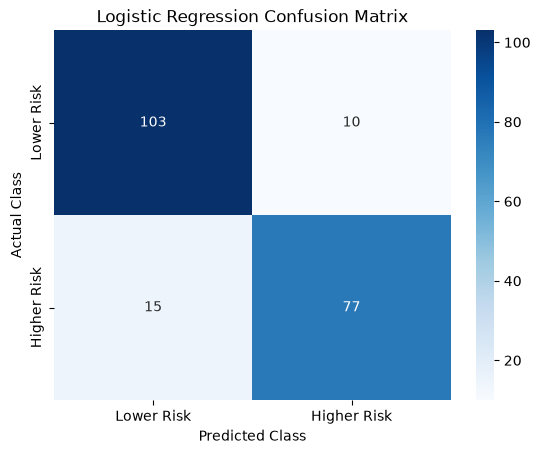

In [34]:
# Draw the best model's confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower Risk",
        "Higher Risk"
    ],
    yticklabels=[
        "Lower Risk",
        "Higher Risk"
    ]
)

plt.title(f"{best_model_name} Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()
     


## Save the Best Model

Save the best-performing trained model so it can be loaded later without retraining it.

In [35]:
# Save the best model

model_path = "../models/best_heart_disease_model.pkl"

joblib.dump(best_model, model_path)

print("Best model saved successfully.")
print("Model:", best_model_name)
print("Saved to:", model_path)

Best model saved successfully.
Model: Logistic Regression
Saved to: ../models/best_heart_disease_model.pkl


In [39]:
# Display the selected best model

print("Best model:", best_model_name)
print("Best F1-score:", results.loc[
    results["F1-score"].idxmax(),
    "F1-score"
])

Best model: Logistic Regression
Best F1-score: 0.8603351955307262


we have t check 

## Verify the Saved Model

Load the saved model again to confirm that it was saved correctly and can be used for predictions.

In [36]:
# Load the saved model

loaded_model = joblib.load(model_path)

print("Saved model loaded successfully.")

Saved model loaded successfully.
